In [2]:
import  pandas  as  pd 
import numpy  as  np


In [3]:
df  = pd.read_csv('/home/joox/Desktop/Ai/classical-ml&& DL /classical-ml/projects/1 project-nyc-taxi-trip-duration/split_sample/train.csv')

In [4]:
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   str    
 1   vendor_id           5000 non-null   int64  
 2   pickup_datetime     5000 non-null   str    
 3   passenger_count     5000 non-null   int64  
 4   pickup_longitude    5000 non-null   float64
 5   pickup_latitude     5000 non-null   float64
 6   dropoff_longitude   5000 non-null   float64
 7   dropoff_latitude    5000 non-null   float64
 8   store_and_fwd_flag  5000 non-null   str    
 9   trip_duration       5000 non-null   int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 532.4 KB


In [7]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

### Initial observations

- The sample contains 5,000 trips and 10 columns.
- No missing values were found.
- No duplicated rows were found.
- `pickup_datetime` was loaded as a string and should be converted to datetime.

In [11]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

In [12]:
df["pickup_datetime"].dtype

dtype('<M8[us]')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  5000 non-null   str           
 1   vendor_id           5000 non-null   int64         
 2   pickup_datetime     5000 non-null   datetime64[us]
 3   passenger_count     5000 non-null   int64         
 4   pickup_longitude    5000 non-null   float64       
 5   pickup_latitude     5000 non-null   float64       
 6   dropoff_longitude   5000 non-null   float64       
 7   dropoff_latitude    5000 non-null   float64       
 8   store_and_fwd_flag  5000 non-null   str           
 9   trip_duration       5000 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(3), str(2)
memory usage: 439.6 KB


In [14]:
df['vendor_id'].value_counts()

vendor_id
2    2600
1    2400
Name: count, dtype: int64

In [15]:
df['vendor_id'].unique()

array([1, 2])

- `vendor_id` contains two categories: 1 and 2.
- Their distribution is fairly balanced: 2400 vs 2600 trips.

In [19]:
df.groupby(['vendor_id'])['trip_duration'].median()

vendor_id
1    656.0
2    655.5
Name: trip_duration, dtype: float64

In [21]:
df['hour'] = df['pickup_datetime'].dt.hour

In [27]:
df.groupby(['hour'])['trip_duration'].median()

hour
0     664.0
1     599.0
2     635.5
3     669.0
4     750.0
5     532.5
6     498.0
7     520.0
8     675.0
9     671.0
10    686.0
11    665.0
12    668.0
13    681.0
14    717.0
15    756.5
16    684.0
17    671.5
18    638.5
19    670.0
20    616.5
21    578.5
22    664.0
23    708.0
Name: trip_duration, dtype: float64

In [28]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'hour'],
      dtype='str')

In [33]:
pickup_points = df[['pickup_latitude', 'pickup_longitude']].to_numpy()
print(pickup_points)
print(pickup_points.shape)

[[ 40.75106812 -73.99064636]
 [ 40.74507141 -73.98265839]
 [ 40.72858047 -73.9994812 ]
 ...
 [ 40.68924332 -73.95132446]
 [ 40.74370956 -73.98374176]
 [ 40.78493881 -73.95586395]]
(5000, 2)


In [34]:
dropoff_points = df[['dropoff_latitude', 'dropoff_longitude']].to_numpy()
print(dropoff_points)
print(dropoff_points.shape)

[[ 40.7281456  -73.99578857]
 [ 40.73297119 -74.00325775]
 [ 40.71879959 -74.00025177]
 ...
 [ 40.68382263 -73.97595978]
 [ 40.76050949 -73.98753357]
 [ 40.80211639 -73.95340729]]
(5000, 2)


In [35]:
!pip install haversine

In [37]:
from haversine import haversine, Unit, haversine_vector

distances = haversine_vector(pickup_points, dropoff_points, unit=Unit.KILOMETERS)
print(distances)

[2.58542756 2.19599141 1.08952301 ... 2.1628819  1.89517821 1.92122579]


In [39]:
len(distances), len(df)

(5000, 5000)

In [40]:
df['distance_km'] = distances

In [41]:
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525,22,2.585428
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799,12,2.195991
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374,0,1.089523
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696,15,2.902090
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703,13,2.114922


In [44]:
df['distance_km'].describe()

count    5000.000000
mean        3.413398
std         3.877827
min         0.000000
25%         1.245021
50%         2.100700
75%         3.832186
max        42.353730
Name: distance_km, dtype: float64

feat: add trip distance feature using haversine

In [51]:
df[df["distance_km"] == 0]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
159,id3861625,2,2016-04-05 13:15:30,1,-73.980934,40.781628,-73.980934,40.781628,N,1953,13,0.0
179,id1245825,1,2016-03-25 12:02:22,1,-70.851616,43.017578,-70.851616,43.017578,N,1486,12,0.0
198,id1558683,1,2016-03-07 20:12:42,3,-73.983017,40.762505,-73.983017,40.762505,N,608,20,0.0
270,id3633178,2,2016-03-31 22:02:29,1,-73.791618,40.661228,-73.791618,40.661228,N,2208,22,0.0
325,id3218773,2,2016-01-07 14:37:17,2,-74.177292,40.695190,-74.177292,40.695190,N,18,14,0.0
387,id1976758,1,2016-01-11 21:29:02,1,-73.935616,40.857029,-73.935616,40.857029,N,2,21,0.0
683,id3836531,2,2016-03-17 07:50:35,1,-73.968048,40.792152,-73.968048,40.792152,N,570,7,0.0
1122,id1681316,2,2016-01-29 05:10:04,1,-73.979713,40.754848,-73.979713,40.754848,N,611,5,0.0
1471,id1881728,2,2016-05-10 06:42:14,1,-73.925232,40.747330,-73.925232,40.747330,N,336,6,0.0
1539,id3793868,1,2016-01-30 13:46:49,1,-73.974960,40.718998,-73.974960,40.718998,N,2291,13,0.0


- Some trips have zero Haversine distance because their recorded pickup and dropoff coordinates are identical.
- This does not necessarily mean the taxi did not move, because Haversine measures only the straight-line distance between the recorded start and end points.
- These records will be kept for now and investigated further rather than removed automatically.

In [57]:
df[df["distance_km"] <= 42.35]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525,22,2.585428
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799,12,2.195991
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374,0,1.089523
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696,15,2.902090
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703,13,2.114922
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,id0201807,2,2016-01-29 11:53:44,1,-73.978348,40.756149,-73.984970,40.741791,N,542,11,1.691249
4996,id0195215,2,2016-05-12 18:07:39,1,-73.965240,40.754917,-73.963531,40.754341,N,74,18,0.157557
4997,id2987373,2,2016-03-03 21:30:48,5,-73.951324,40.689243,-73.975960,40.683823,N,409,21,2.162882
4998,id1026507,1,2016-06-04 20:45:44,1,-73.983742,40.743710,-73.987534,40.760509,N,763,20,1.895178


In [58]:
df.nlargest(10, 'distance_km')

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
2247,id1561128,2,2016-01-28 21:43:02,1,-73.950462,40.775799,-73.654800,41.084320,N,85828,21,42.353730
63,id3181715,2,2016-05-22 13:53:45,1,-73.783699,40.648720,-73.923637,40.840260,N,2984,13,24.343327
3653,id1078536,1,2016-02-26 23:25:45,4,-73.788872,40.641117,-73.944221,40.824944,N,1914,23,24.272524
3200,id1666147,2,2016-03-31 18:28:08,6,-73.776680,40.645416,-73.968254,40.802074,N,2840,18,23.750246
987,id2054250,1,2016-02-04 06:39:34,1,-73.968758,40.791264,-73.776573,40.644924,N,2231,6,22.959189
4543,id1665858,2,2016-04-28 09:09:50,1,-73.998238,40.761009,-73.776421,40.645199,N,3422,9,22.703829
2376,id3984532,2,2016-06-02 01:22:38,1,-73.780533,40.646149,-73.990334,40.773178,N,2021,1,22.632572
3538,id1498879,2,2016-04-25 14:39:14,5,-73.789513,40.643421,-73.981750,40.784859,N,4531,14,22.580071
3774,id3049585,1,2016-03-28 20:16:06,2,-73.782616,40.644459,-73.984184,40.778019,N,2690,20,22.565521
1004,id1848896,2,2016-06-17 06:20:46,1,-73.792099,40.645187,-73.972336,40.793682,N,2705,6,22.435864


In [59]:
df.nlargest(10, 'trip_duration')

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
1262,id3594467,2,2016-05-18 00:15:00,2,-74.013252,40.707062,-73.958649,40.688332,N,86329,0,5.052512
3687,id1829617,2,2016-06-10 21:12:54,3,-73.996613,40.723701,-73.989532,40.747810,N,86233,21,2.746359
3311,id3805971,2,2016-01-01 03:26:28,5,-73.983711,40.676174,-73.966148,40.690178,N,86209,3,2.148927
4421,id0053174,2,2016-05-01 12:33:49,1,-73.984909,40.747860,-73.978477,40.758518,N,86135,12,1.303100
2430,id3389632,2,2016-02-27 18:18:50,2,-73.979408,40.766972,-73.984039,40.759590,N,85917,18,0.908737
3315,id3213293,2,2016-04-23 13:00:51,2,-74.014160,40.702648,-73.996117,40.741898,N,85891,13,4.621648
2247,id1561128,2,2016-01-28 21:43:02,1,-73.950462,40.775799,-73.654800,41.084320,N,85828,21,42.353730
601,id2760914,2,2016-06-26 03:29:20,1,-73.989479,40.720390,-73.990334,40.728790,N,85295,3,0.936806
2799,id0259764,2,2016-05-31 13:56:41,1,-73.979622,40.759258,-73.807869,40.722298,N,75015,13,15.042368
3637,id2596986,1,2016-04-12 08:51:36,1,-73.781776,40.644714,-73.985909,40.759949,N,7489,8,21.454532


In [71]:
df[df["trip_duration"] >= 72000]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,distance_km
601,id2760914,2,2016-06-26 03:29:20,1,-73.989479,40.720390,-73.990334,40.728790,N,85295,3,0.936806
1262,id3594467,2,2016-05-18 00:15:00,2,-74.013252,40.707062,-73.958649,40.688332,N,86329,0,5.052512
2247,id1561128,2,2016-01-28 21:43:02,1,-73.950462,40.775799,-73.654800,41.084320,N,85828,21,42.353730
2430,id3389632,2,2016-02-27 18:18:50,2,-73.979408,40.766972,-73.984039,40.759590,N,85917,18,0.908737
2799,id0259764,2,2016-05-31 13:56:41,1,-73.979622,40.759258,-73.807869,40.722298,N,75015,13,15.042368
3311,id3805971,2,2016-01-01 03:26:28,5,-73.983711,40.676174,-73.966148,40.690178,N,86209,3,2.148927
3315,id3213293,2,2016-04-23 13:00:51,2,-74.014160,40.702648,-73.996117,40.741898,N,85891,13,4.621648
3687,id1829617,2,2016-06-10 21:12:54,3,-73.996613,40.723701,-73.989532,40.747810,N,86233,21,2.746359
4421,id0053174,2,2016-05-01 12:33:49,1,-73.984909,40.747860,-73.978477,40.758518,N,86135,12,1.303100


- 9 trips (0.18% of the sample) have durations greater than 20 hours.
- These trips are rare and suspicious because their distances vary widely while their durations are extremely high.
- They will not be removed automatically at this stage.

In [74]:
!pip  install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 3.8 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 3.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 3.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


In [75]:
import matplotlib.pyplot as plt

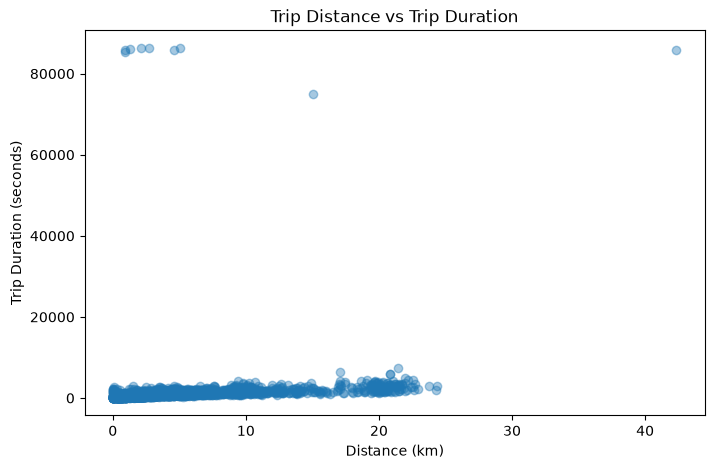

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["trip_duration"],
    alpha=0.4
)

plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration (seconds)")
plt.title("Trip Distance vs Trip Duration")

plt.show()

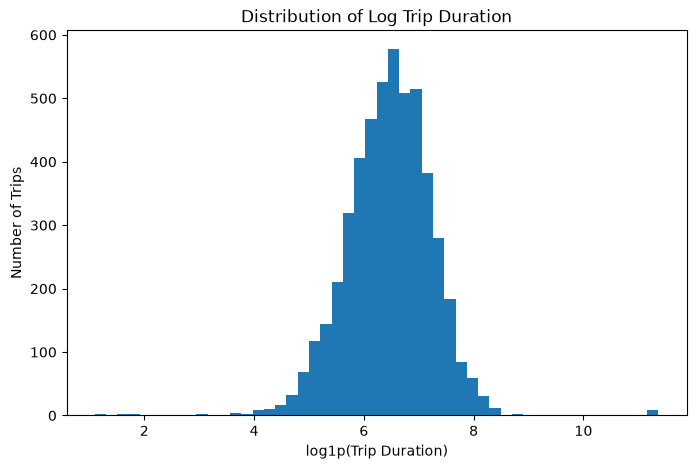

In [79]:
plt.figure(figsize=(8, 5))

plt.hist(np.log1p(df["trip_duration"]), bins=50)

plt.xlabel("log1p(Trip Duration)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Log Trip Duration")

plt.show()

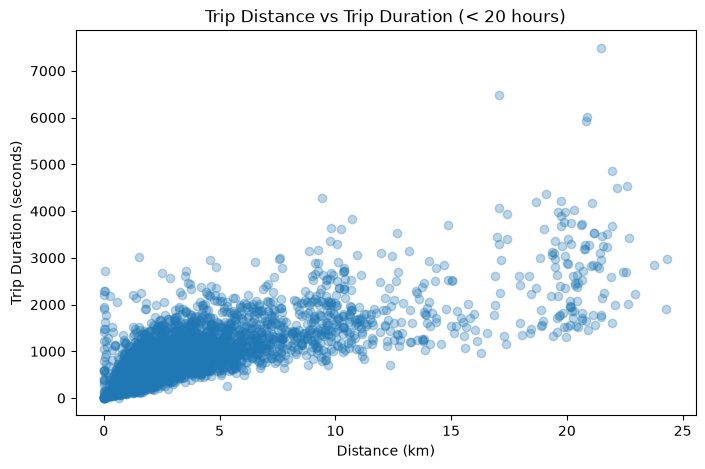

In [80]:
df_plot = df[df["trip_duration"] < 72000]

plt.figure(figsize=(8, 5))

plt.scatter(
    df_plot["distance_km"],
    df_plot["trip_duration"],
    alpha=0.3
)

plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration (seconds)")
plt.title("Trip Distance vs Trip Duration (< 20 hours)")

plt.show()

## Session Summary — Data Understanding & Initial EDA

### 1. Initial Data Inspection
- Loaded the training sample containing **5,000 trips** and **10 original columns**.
- Checked the first rows, data types, missing values, and duplicates.
- No missing values were found.
- No duplicated rows were found.

### 2. Datetime Preparation
- `pickup_datetime` was initially loaded as a string.
- Converted it to a proper datetime type so that time-based features can be extracted later.

### 3. Vendor Investigation
- `vendor_id` contains two categories:
  - Vendor 1: 2,400 trips
  - Vendor 2: 2,600 trips
- The distribution is fairly balanced.
- Median `trip_duration` was almost identical for both vendors (~656 seconds), so no strong duration difference was observed from `vendor_id` alone.

### 4. Initial Time Feature
- Extracted `hour` from `pickup_datetime`.
- Median trip duration changes across different hours.
- However, this alone cannot prove a traffic/rush-hour effect because trip distances may also differ between hours.

### 5. Distance Feature Engineering
- Created pickup and dropoff coordinate arrays using:
  - latitude
  - longitude
- Used Haversine distance because GPS coordinates are geographical coordinates, not normal Cartesian coordinates.
- Compared a row-by-row loop implementation with `haversine_vector`.
- Used the vectorized approach for better scalability.
- Added a new feature:

`distance_km`

### 6. Distance Statistics
The distance feature showed approximately:

- Mean: **3.41 km**
- Median: **2.10 km**
- Standard deviation: **3.88 km**
- 25%: **1.25 km**
- 75%: **3.83 km**
- Maximum: **42.35 km**

The mean being noticeably higher than the median suggests a **right-skewed distribution**, with a smaller number of long trips.

### 7. Zero-Distance Trips
- Some trips have a Haversine distance of 0 km.
- Their recorded pickup and dropoff coordinates are identical.
- This does NOT necessarily mean the taxi did not move because Haversine only measures the distance between the recorded start and end points.
- These records were not removed.

### 8. Suspicious Long-Duration Trips
- Found **9 trips** with `trip_duration >= 20 hours`.
- This represents approximately **0.18%** of the sample.
- Their distances vary significantly, while their durations are extremely high.
- These records are considered suspicious, but they were NOT removed automatically.

### 9. Target Distribution
- Raw `trip_duration` is strongly right-skewed because of very large duration values.
- Applying `log1p(trip_duration)` compresses extreme values and produces a much more compact target distribution.
- This is the target representation used for the regression project.

### 10. Distance vs Trip Duration
After temporarily excluding trips longer than 20 hours from the visualization:

- Trip duration generally increases as distance increases.
- `distance_km` appears to be an important predictive feature.
- For longer distances, the spread in trip duration becomes much larger.
- Therefore, distance alone cannot fully explain trip duration.

Possible additional factors include:

- Time of day
- Day of week
- Month / season
- Pickup and dropoff areas
- Traffic conditions

---

## Current Conclusion

`distance_km` explains an important part of trip duration, but trips with similar distances can still have very different durations.

Therefore, the next step is to investigate **time-related features**.

## Next Session

Start with:

**Extract `dayofweek` from `pickup_datetime` and investigate its relationship with `trip_duration`.**

Then continue with other useful time features only if the data suggests they may help.